In [2]:
import pandas as pd
import math
import os
import numpy as np
import xarray as xr
import netCDF4
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action="ignore")
os.chdir(r"D:/Theses/Dossier_ma_These/Data/map_faidherbia/pheno")

In [49]:
df_obs = pd.read_excel("Gaglo2023_version.xlsx", sheet_name="Sheet1")

In [50]:

# Calculate the cylinder volume for each row
df_obs['Volum_calc_m3'] = math.pi * ((df_obs['DBH_m'] / 2) ** 2) * df_obs['Haut_tronc_m']

df_obs.head(2)


,trunck,Trunck_wood_volum_m3,Crown_wood_volum_m3,Tree_wood_volum_m3,DBH_m,Haut_Total_m,Haut_tronc_m,Volum_calc_m3
0,Tree_EC20_trunk,1.135028,760.9706,765.2563,0.594,12.84,3.58,0.992078
1,Tree_EC19_trunk,0.693358,464.9022,462.3807,0.565,13.61,2.61,0.654376


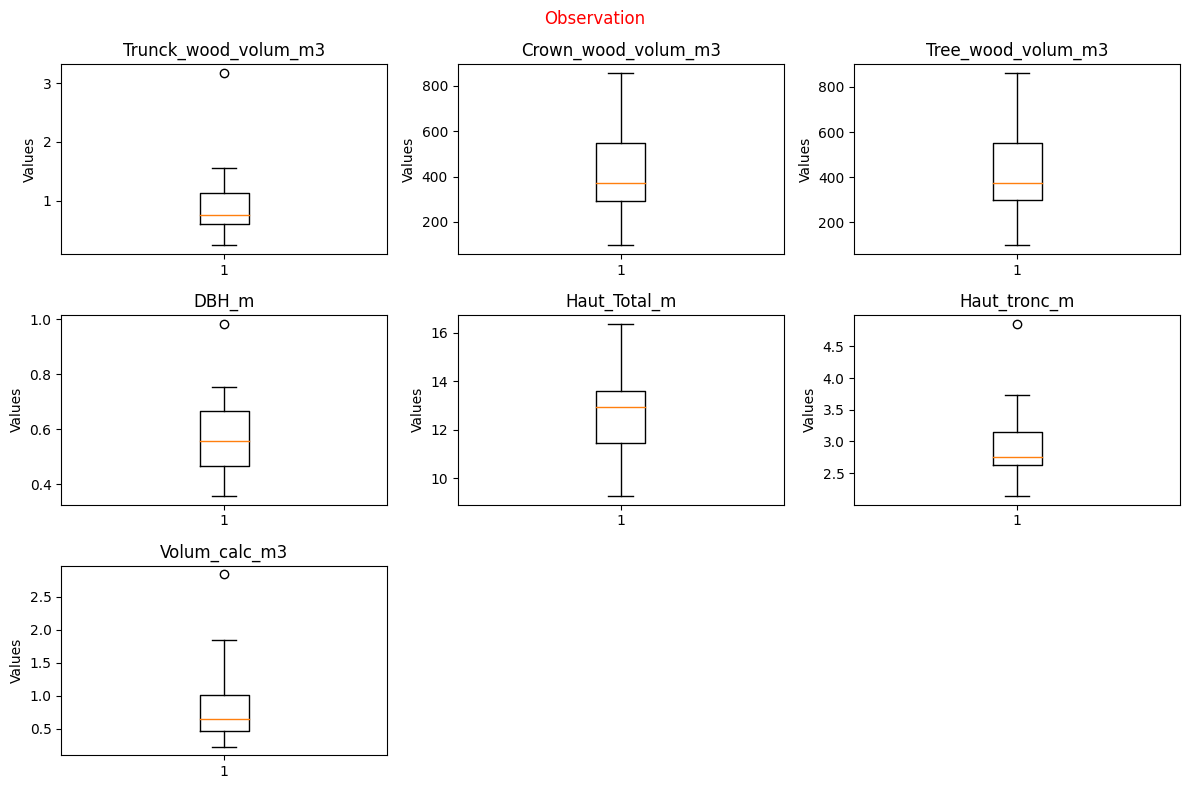

In [54]:


# Select the columns you want to plot
columns_to_plot = ['Trunck_wood_volum_m3', 'Crown_wood_volum_m3', 'Tree_wood_volum_m3', 'DBH_m', 'Haut_Total_m', 'Haut_tronc_m', 'Volum_calc_m3']

# Create individual boxplots for each selected column
plt.figure(figsize=(12, 8))  # Adjust the figure size as needed

for i, column in enumerate(columns_to_plot):
    plt.subplot(3, 3, i + 1)  # Create a subplot for each column
    plt.boxplot(df_obs[column])
    plt.title(column)
    plt.ylabel('Values')

plt.suptitle("Observation", color='r')
plt.tight_layout()

# Display the boxplots
plt.show()


In [33]:
sech_4dim_trans = xr.open_dataset('FG2.transClim.FF_1901_1961_1M_sechiba_history_4dim.nc')
sech_trans = xr.open_dataset("FG2.transClim.FF_1901_1961_1M_sechiba_history.nc")
stom_trans = xr.open_dataset("FG2.transClim.FF_1901_1961_1M_stomate_history.nc")
stom_4dim_trans = xr.open_dataset("FG2.transClim.FF_1901_1961_1M_stomate_history_4dim.nc")

In [36]:
vars = ["LEAF_M_c",
"HEART_M_AB_c",
"HEART_M_BE_c",
"ROOT_M_c",
"FRUIT_M_c",
"HEIGHT",
"DIAMETER",
"WOOD_VOL", "IND"]
vars2 = ["CCCROWNVOL"]

df = stom_trans.get(vars).sel(veget=3, time_counter=slice(f"{1961}-12-01", f"{1962}-01-01"))
df2 = stom_4dim_trans.get(vars2).sel(veget=3, time_counter=slice(f"{1961}-12-01", f"{1962}-01-01"))

In [35]:
df2.to_dataframe().reset_index().tail(1)

,time_counter,ncirc,lat_domain_landpoints,lon_domain_landpoints,CCCROWNVOL,veget,time_centered
92,1961-12-31,3.0,15.0,-17.0,25129.324219,3.0,1961-12-31 12:00:00


In [37]:
data = df.to_dataframe().reset_index()
data["CCCROWNVOL"] = df2.to_dataframe().reset_index()["CCCROWNVOL"]

In [42]:
data.tail(1)

,time_counter,lat,lon,LEAF_M_c,HEART_M_AB_c,HEART_M_BE_c,ROOT_M_c,FRUIT_M_c,HEIGHT,DIAMETER,WOOD_VOL,IND,veget,time_centered,CCCROWNVOL
30,1961-12-31,15.0,-17.0,50.092194,29708.5,7474.778809,36.652172,0.0,40.639214,0.627797,0.070342,0.016807,3.0,1961-12-31 12:00:00,1712.083252


In [46]:
var_columns

['HEIGHT', 'DIAMETER', 'WOOD_VOL', 'IND', 'CCCROWNVOL']

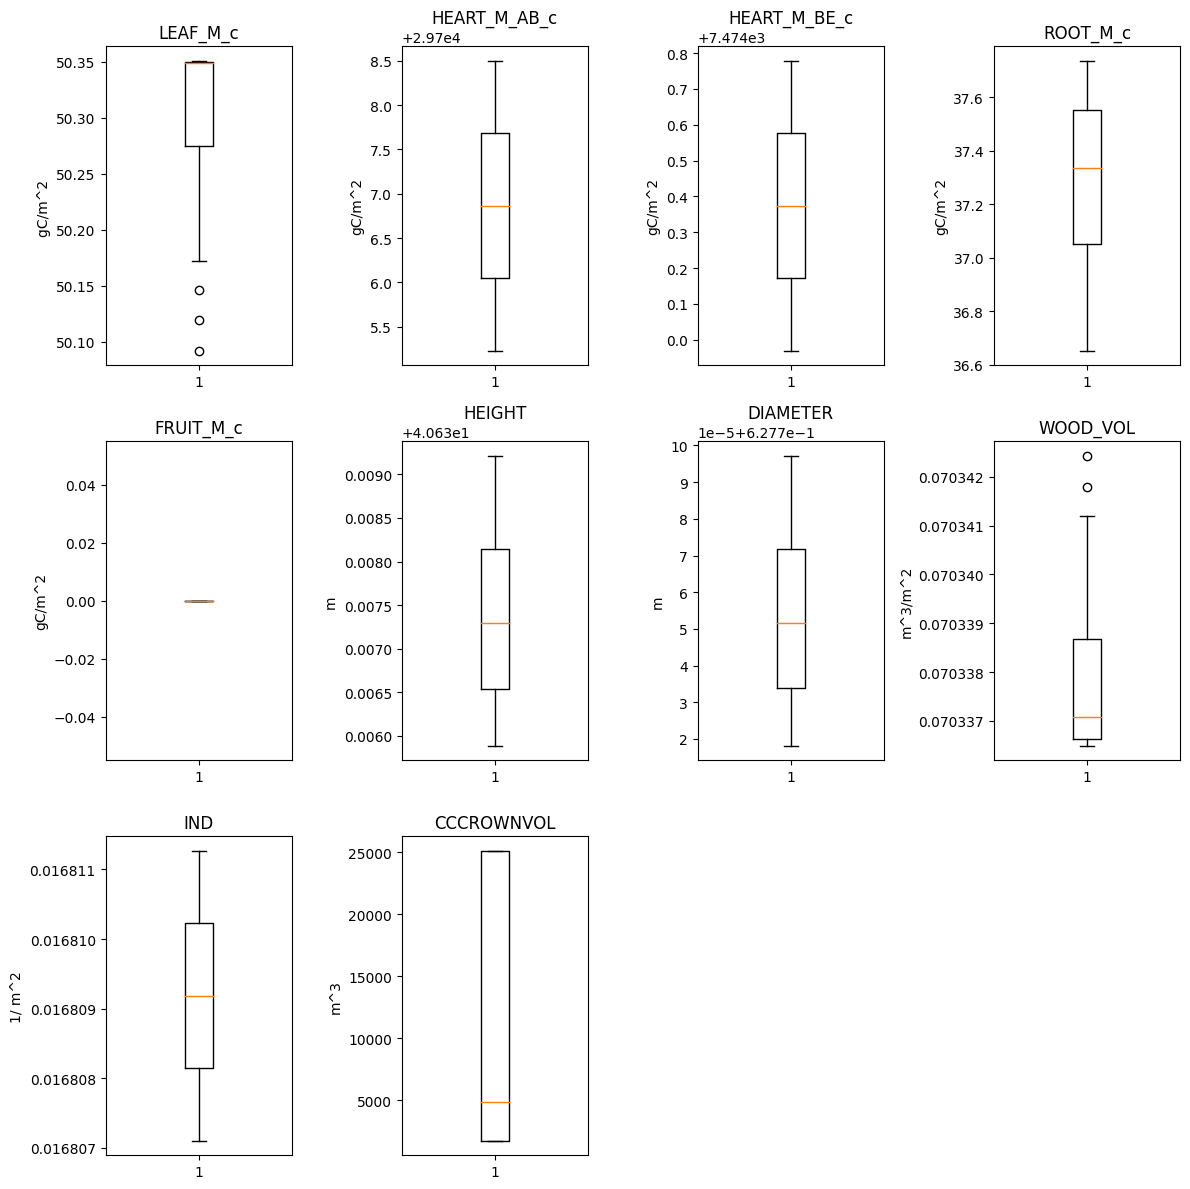

In [58]:

var_columns = [col for col in data.columns if col[0].isupper()]
# Create individual boxplots for each selected column
plt.figure(figsize=(12, 12))  # Adjust the figure size as needed

for i, column in enumerate(var_columns):
    plt.subplot(3, 4, i + 1)  # Create a subplot for each column
    plt.boxplot(data[column])
    plt.title(column)
    try:
        plt.ylabel(df[column].units)
    except KeyError:
        plt.ylabel(df2[column].units)

plt.tight_layout()

# Display the boxplots
plt.show()

In [ ]:
# CROWN_TO_HEIGHT ([-]  ) :  Ratio between tree height and the vertical crown diameter. 	{OK_STOMATE }
CROWN_TO_HEIGHT =  -9999., 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 0.8, 0.8, 0., 0., 0., 

# PIPE_DENSITY  () :   	{}
PIPE_DENSITY  =  -9999., 3.e5, 3.e5, 2.e5, 3.e5, 3.e5, 2.e5, 3.e5, 2.e5, 2.e5, 2.e5, 2.e5, 2.e5 

# TREE_FF ([-]  ) :  Tree form factor reducing the volume of a cylinder 	{OK_STOMATE }
TREE_FF =  -9999., 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 0.8, 0.8, 0., 0., 0., 0. 

# PIPE_TUNE2  ([-]      ) :  height 	{OK_STOMATE }
PIPE_TUNE2  =  -9999., 40., 40., 40., 40., 40., 40., 40., 40., 0., 0., 0., 0.   

# PIPE_TUNE3 ([-]    ) :  height 	{OK_STOMATE }
PIPE_TUNE3 =  -9999., 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0., 0., 0., 0.    

# PIPE_TUNE4 ([-]  ) :  needed for stem diameter 	{OK_STOMATE }
PIPE_TUNE4 =  -9999., 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0., 0., 0., 0. 

# PIPE_K1  ([-]   ) :   	{OK_STOMATE }
PIPE_K1  =  -9999., 8.e3, 8.e3, 8.e3, 8.e3, 8.e3, 8.e3, 8.e3, 8.e3, 0., 0., 0., 0.  

# SLA ([m^2/gC]) :  specif leaf area  	{OK_STOMATE}
SLA =  1.5E-2, 1.53E-2, 2.6E-2, 9.26E-3, 2E-2, 2.6E-2, 9.26E-3, 2.6E-2, 1.9E-2, 2.6E-2, 2.6E-2, 2.6E-2, 2.6E-2 

# SLAINIT ([m^2/gC]) :  initial specif leaf area at (ie at bottom of canopy eq. lai 	{OK_STOMATE}
SLAINIT =  2.6E-2, 2.6E-2, 4.4E-2, 1.4E-2, 3.0E-2, 3.9E-2, 1.3E-2, 3.7E-2, 2.4E-2, 3.1E-2, 3.1E-2, 3.9E-2, 3.9E-2 

# LAI_TO_HEIGHT ([m m2 m-2] ) :  Convertion factor from lai to vegetation height for grasses and crops 	{OK_STOMATE}
LAI_TO_HEIGHT =  -9999., -9999., -9999., -9999., -9999., -9999., -9999., -9999., 0.2, 0.5, 0.2, 0.5 


In [ ]:
   !! 1. Calculate the LAI from the leaf biomass
    IF(sla_dyn) THEN
       biomass_to_lai_0d = log(1.+ ext_coeff_N(pft) * leaf_biomass * slainit(pft))/(ext_coeff_N(pft)) 
    ELSE
       biomass_to_lai_0d = leaf_biomass * sla(pft)
    ENDIF


                   lai(ji,jv) = cc_to_lai(circ_class_biomass(ji,jv,:,ileaf,icarbon), &
                     circ_class_n(ji,jv,:),jv)

In [ ]:
import math

def wood_to_ba(l, woodmass_ind, pft, pipe_density, pipe_tune2, pipe_tune3):
    return (math.pi / 4 * (woodmass_ind / (tree_ff(pft) * pipe_density(pft) * pipe_tune2(pft)) ** (2.0 / pipe_tune3(pft))) ** (pipe_tune3(pft) / (pipe_tune3(pft) + 2))


In [ ]:
K=tree_ff(pft) * pipe_density(pft) * pipe_tune2(pft)

math.pi / 4 * (woodmass_ind / (K) ** (2.0 / pipe_tune3(pft))) ** (pipe_tune3(pft) / (pipe_tune3(pft) + 2))


In [ ]:
wood_to_ba(l) = (pi/4*(woodmass_ind/(tree_ff(pft)*pipe_density(pft)*pipe_tune2(pft))) & 
    **(2./pipe_tune3(pft)))**(pipe_tune3(pft)/(pipe_tune3(pft)+2))  

In [5]:
Tree form factor to reduce the volume of a cylinder to the volume of the real tree shape

3.3333333333333335

#function_library.f90 #  1216 line  

!! (i) woodmass = tree_ff * pipe_density*ba*height
!! (ii) height = pipe_tune2 * sqrt(4/pi*ba) ** pipe_tune_3 


wood_to_ba(l) = (pi/4*(woodmass_ind/(tree_ff(pft)*pipe_density(pft)*pipe_tune2(pft))) & 
    **(2./pipe_tune3(pft)))**(pipe_tune3(pft)/(pipe_tune3(pft)+2))  




dia(:) = (woodmass_ind(:,j)/(pipe_density(j)*pi/4.*pipe_tune2)) &
    &       **(1./(2.+pipe_tune3))

qm_dia = SQRT( 4/pi*SUM(circ_class_ba(:)*ind(:))/SUM(ind(:)) )

wood_to_qmheight = pipe_tune2(pft)*(qm_dia**pipe_tune3(pft))
#wood_to_qmdia = SQRT( 4/pi*SUM(circ_class_ba(:)*ind(:))/SUM(ind(:)) )

cn_area = pipe_tune1*...
stem diameter**pipe_tune_exp_coeff
!! for consistency reason pipe_tune1 is calculated as 0.66*pi/4*pipe_tune2**2

In [1]:
def wood_to_qmheight(pipe_tune2, pipe_tune3, qm_dia):

    result = pipe_tune2 * (qm_dia ** pipe_tune3)
    return result


In [3]:
wood_to_qmheight(20, 0.212, 0.627797)

18.120395552057847

In [74]:
def wood_to_qmheight(pipe_tune2, pipe_tune3, qm_dia):
    result = pipe_tune2 * (qm_dia ** pipe_tune3)
    return result

# Define the desired result range
lower_limit = 2.5
upper_limit = 4.5

# Define the ranges for pipe_tune2, pipe_tune3, and qm_dia
pipe_tune2_range = range(1, 11)  # Adjust the range as needed
pipe_tune3_range = range(1, 2)  # Adjust the range as needed
qm_dia_range = [0.4, 0.6, 0.8, 1.0]  # Adjust the values as needed

best_combination = None

for pipe_tune2 in pipe_tune2_range:
    for pipe_tune3 in pipe_tune3_range:
        for qm_dia in qm_dia_range:
            result = wood_to_qmheight(pipe_tune2, pipe_tune3, qm_dia)
            if lower_limit <= result <= upper_limit:
                best_combination = (pipe_tune2, pipe_tune3, qm_dia)
                break  # Exit the innermost loop if a valid combination is found
        if best_combination:
            break  # Exit the middle loop if a valid combination is found
    if best_combination:
        break  # Exit the outermost loop if a valid combination is found

if best_combination:
    print(f"Best combination: pipe_tune2 = {best_combination[0]}, pipe_tune3 = {best_combination[1]}, qm_dia = {best_combination[2]}")
else:
    print("No valid combination found in the specified range.")


Best combination: pipe_tune2 = 3, pipe_tune3 = 1, qm_dia = 1.0


### Correction CRUJRA climate dataset with Faidherbia Flux obs data

In [ ]:
# atmvars = [
# 	    dict(name = "Tair",   readvar = "tmp",                           units = "K",        cell_methods = "timeplussix: instantaneous", long_name = "Temperature at 2m"),
# 	    dict(name = "Tmin",   readvar = "tmin",                          units = "K",        cell_methods = "time: min(start)",           long_name = "Minimum temperature at 2m"),
# 	    dict(name = "Tmax",   readvar = "tmax",                          units = "K",        cell_methods = "time: max(start)",           long_name = "Maximum temperature at 2m"),
# 	    dict(name = "PSurf",  readvar = "pres",                          units = "Pa",       cell_methods = "timeplussix: instantaneous", long_name = "Pressure"),
# 	    dict(name = "Qair",   readvar = "spfh",                          units = "kg/kg",    cell_methods = "timeplussix: instantaneous", long_name = "Specific Humidity"),
#         dict(name = "Wind_N", readvar = "vgrd",                          units = "m/s",      cell_methods = "timeplussix: instantaneous", long_name = "Meridional component of wind speed"),
# 	    dict(name = "Wind_E", readvar = "ugrd",                          units = "m/s",      cell_methods = "timeplussix: instantaneous", long_name = "Zonal component of wind speed"),
# 	    dict(name = "Rainf",  readvar = "rainf", coef = 1./(6.*60.*60.), units = "kg/m^2/s", cell_methods = "time: mean(start)",          long_name = "Rain Fall"),
# 	    dict(name = "Snowf",  readvar = "snowf", coef = 1./(6.*60.*60.), units = "kg/m^2/s", cell_methods = "time: mean(start)",          long_name = "Snow Fall"),
#         dict(name = "LWdown", readvar = "dlwrf",                         units = "W/m^2",    cell_methods = "time: mean(start)",          long_name = "Downward longwave radiation"),
# 	    dict(name = "SWdown", readvar = "tswrf",                         units = "W/m^2",    cell_methods = "time: mean(start)",          long_name = "Downward shortwave radiation"),
# 	    dict(name = "fd",     readvar = "fd",                            units = "1",        cell_methods = "time: mean(start)",          long_name = "Diffuse fraction of downward shortwave radiation"),
# 	]

In [ ]:
#Preprocession FFlux dataset

In [149]:
df_obs = pd.read_excel(r"D:/Theses/Dossier_ma_These/Data/Data_Obs_Extract.FF.updateNov2023.xlsx", sheet_name="Data")

In [152]:
df_obs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105168 entries, 0 to 105167
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   DateSemih                 105168 non-null  object 
 1   Tair_2m_SmallAnt_degC.Gf  85120 non-null   float64
 2   P_20m_hPa                 85120 non-null   float64
 3   WindSpeed_20m_ms1         85120 non-null   float64
 4   Rain_mmsemih              85120 non-null   float64
 5   VPD_20m_hPa               85120 non-null   float64
 6   Rg_estim_20m.Gf           85120 non-null   float64
 7   LWdownW.Gf                85120 non-null   float64
 8   Rh_20m_pc                 85120 non-null   float64
dtypes: float64(8), object(1)
memory usage: 7.2+ MB


In [73]:
list_variables = ["LWdown", "PSurf", "Rainf", "SWdown", "Tair", "Wind_D"]
#variable units : 

In [155]:
ff_w_obs = df_obs.copy()
ff_w_obs['DateSemih'] = pd.to_datetime(ff_w_obs['DateSemih'])
ff_w_obs = ff_w_obs.dropna(axis=0)
ff_w_obs = ff_w_obs.set_index('DateSemih').resample('D').agg({var: 'sum' if var == 'Rain_mmsemih' else 'mean' for var in ff_w_obs.columns[1:]})


In [156]:
ff_w_obs.head(3)

,Tair_2m_SmallAnt_degC.Gf,P_20m_hPa,WindSpeed_20m_ms1,Rain_mmsemih,VPD_20m_hPa,Rg_estim_20m.Gf,LWdownW.Gf,Rh_20m_pc
DateSemih,,,,,,,,
2018-01-03,24.667391,1007.879000,4.098333,0.0,15.824712,322.565352,379.501373,57.889792
2018-01-04,26.056878,1007.879000,4.385417,0.0,20.324490,324.365821,382.892489,51.155833
2018-01-05,28.831156,1007.826293,4.871667,0.0,29.717047,356.160081,389.995106,32.727292


In [160]:
#Preprocess functions
def C_to_K(t):
    T = t + 273.15
    return T
def hPa_to_Pa(p):
    P = 100*p
    return P
def calculate_specific_humidity(t, rh, p):
    """ Source:https://cran.r-project.org/web/packages/humidity/vignettes/humidity-measures.html
    Input:
        t: Air temperature in Celsius
        rh: Relative humidity in percentage
        p: Atmospheric pressure in hPa
    Output:
        q: specific humidity in kg/kg
    """
    # Convert relative humidity from percentage to a decimal fraction
    rh = rh / 100.0
    
    # Convert temperature from Celsius to Kelvin
    T = t + 273.15

    # Calculate saturation vapor pressure (e_s) using the temperature (T)
    # You can use the Magnus formula for this calculation with Tetens(1930)
    #https://www.osti.gov/servlets/purl/548871
    #e_s = 6.112 * 10 ** ((7.5 * T) / (T + 237.7))
    # Magnus Tetens (Murray, 1967) http://cires.colorado.edu/~voemel/vp.html   
    e_s = 6.1078 * 10 ** (21.8745584 * (T- 273.16) / (T- 7.66))

    # Calculate actual vapor pressure (e_a) as a fraction of e_s
    e_a = rh * e_s

    # Calculate specific humidity (q) using the formula
    q = (0.622 * e_a) / (p - (0.378 * e_a))

    # Return specific humidity in kg/kg
    return q

In [38]:
ff_w_obs.columns

Index(['Tair_2m_SmallAnt_degC.Gf', 'P_20m_hPa', 'WindSpeed_20m_ms1',
       'Rain_mmsemih', 'VPD_20m_hPa', 'Rg_estim_20m.Gf', 'LWdownW.Gf',
       'Rh_20m_pc'],
      dtype='object')

In [161]:
ff_w_obs["Tair"] = ff_w_obs.apply(lambda row: C_to_K(row['Tair_2m_SmallAnt_degC.Gf']), axis=1)
ff_w_obs["PSurf"] = ff_w_obs.apply(lambda row: hPa_to_Pa(row['P_20m_hPa']), axis=1)
ff_w_obs = ff_w_obs.rename(columns={"Rain_mmsemih": "Rainf", "Rg_estim_20m.Gf": "SWdown", 
                         "LWdownW.Gf": "LWdown", "WindSpeed_20m_ms1": "Wind_D"}, errors="raise")

ff_w_obs_to_plot = ff_w_obs[list_variables]

In [162]:
ff_w_obs_to_plot

,LWdown,PSurf,Rainf,SWdown,Tair,Wind_D
DateSemih,,,,,,
2018-01-03,379.501373,100787.900000,0.0,322.565352,297.817391,4.098333
2018-01-04,382.892489,100787.900000,0.0,324.365821,299.206878,4.385417
2018-01-05,389.995106,100782.629283,0.0,356.160081,301.981156,4.871667
2018-01-06,406.138908,100714.479125,0.0,273.388013,300.948932,2.741708
2018-01-07,409.807479,100660.968952,0.0,280.465003,299.584852,3.826979
...,...,...,...,...,...,...
2022-12-27,357.558333,100550.604167,0.0,234.178250,296.405417,2.990104
2022-12-28,373.662500,100312.562500,0.0,224.934835,296.635417,2.261896
2022-12-29,397.510417,100246.375000,0.0,190.750672,297.629583,1.615062


### CRUJRA dataset

In [103]:
# # Niakhar coordinates
# lat_nia, lon_nia = 14.495810, -16.4535
# #ncks -d latitude,32,39 -d longitude,77,84 crujra_twodeg_v2.2.2_2021.nc -O -o extract_FF_Sob_crujra_twodeg_v2.2.2_2021.nc

# # List of files to process
# files = ["crujra_twodeg_v2.2.2_2018.nc", "crujra_twodeg_v2.2.2_2019.nc", "crujra_twodeg_v2.2.2_2020.nc"]


# # Initialize an empty DataFrame to store the results
# result_df = pd.DataFrame()

# for f in files:
#     # Open the NetCDF file using xarray
#     t = xr.open_dataset(f)
    
#     # Convert the xarray dataset to a pandas DataFrame and reset the index
#     df = t.to_dataframe().reset_index()
    
#     # Subset the data for the specified coordinates
#     subset_df = df[
#         (df['nav_lat'] >= lat_nia - 1) & (df['nav_lat'] <= lat_nia + 1) &
#         (df['nav_lon'] >= lon_nia - 1) & (df['nav_lon'] <= lon_nia + 1)
#     ]
    
#     # Rearrange the column 'time' to be the first column
#     subset_df = subset_df[['time'] + [col for col in subset_df.columns if col != 'time']]

    
#     # Append the subsetted data to the result DataFrame
#     result_df = result_df.append(subset_df, ignore_index=True)

# # Print the resulting DataFrame
# result_df


In [122]:
df_cruj = pd.read_csv("extract_FF_Sob_crujra_twodeg_v2.2.2.csv")
df_cruj['time'] = pd.to_datetime(df_cruj['time'])
df_cruj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   4380 non-null   int64         
 1   time         4380 non-null   datetime64[ns]
 2   latitude     4380 non-null   int64         
 3   longitude    4380 non-null   int64         
 4   tstep        4380 non-null   int64         
 5   nav_lon      4380 non-null   float64       
 6   nav_lat      4380 non-null   float64       
 7   timeplussix  4380 non-null   object        
 8   contfrac     4380 non-null   float64       
 9   Tair         4380 non-null   float64       
 10  Tmin         4380 non-null   float64       
 11  Tmax         4380 non-null   float64       
 12  PSurf        4380 non-null   float64       
 13  Qair         4380 non-null   float64       
 14  Wind_N       4380 non-null   float64       
 15  Wind_E       4380 non-null   float64       
 16  Rainf 

In [123]:
def wind_function(Wind_N, Wind_E):
    # Calculate the resultant wind speed for each data point
    wind = np.sqrt(Wind_N**2 + Wind_E**2)
    return wind

In [124]:
df_cruj["Wind_D"] = df_cruj.apply(lambda row: wind_function(row['Wind_N'], row['Wind_E']), axis=1)

In [118]:
df_cruj.head(4)

,Unnamed: 0,time,latitude,longitude,tstep,nav_lon,nav_lat,timeplussix,contfrac,Tair,...,PSurf,Qair,Wind_N,Wind_E,Rainf,Snowf,LWdown,SWdown,fd,Wind_D
0,0,2018-01-01 00:00:00,37,81,0,-17.0,15.0,2018-01-01 06:00:00,0.430365,293.40344,...,101092.086,0.006122,-2.032216,-3.153990,0.0,0.0,350.01700,0.000000,0.000000,3.752007
1,1,2018-01-01 06:00:00,37,81,1,-17.0,15.0,2018-01-01 12:00:00,0.430365,300.07263,...,101225.305,0.005811,-2.343144,-6.209040,0.0,0.0,346.46360,298.489400,0.541308,6.636453
2,2,2018-01-01 12:00:00,37,81,2,-17.0,15.0,2018-01-01 18:00:00,0.430365,303.61942,...,100943.130,0.008018,-2.668502,-3.111930,0.0,0.0,374.36505,545.783200,0.592225,4.099392
3,3,2018-01-01 18:00:00,37,81,3,-17.0,15.0,2018-01-02 00:00:00,0.430365,295.49307,...,101196.220,0.008170,-3.803686,-2.088751,0.0,0.0,358.03510,5.461161,0.950852,4.339460


In [184]:
crujra_df = df_cruj.copy()

crujra_df = crujra_df.set_index('time')

crujra_df_to_plot = crujra_df[list_variables].resample('D').agg({var: 'sum' if var == 'Rainf' else 'mean' for var in list_variables})

In [185]:

crujra_df_to_plot.reset_index().to_csv("crujra_df_to_plot.csv", index=False)

In [192]:
crujra_df_to_plot = pd.read_csv("crujra_df_to_plot.csv")
crujra_df_to_plot['time'] = pd.to_datetime(crujra_df_to_plot['time'])
crujra_df_to_plot = crujra_df_to_plot.set_index('time')
crujra_df_to_plot.head(4)

,LWdown,PSurf,Rainf,SWdown,Tair,Wind_D
time,,,,,,
2018-01-01,357.220188,101114.1853,0.0,212.433440,298.147140,4.706828
2018-01-02,351.520568,101114.3415,0.0,205.225347,297.962215,3.900460
2018-01-03,351.724063,101202.9735,0.0,185.943249,298.287665,3.660726
2018-01-04,348.683695,101292.9438,0.0,206.816912,298.249715,3.657219


In [193]:
ff_w_obs_to_plot = ff_w_obs_to_plot[(ff_w_obs_to_plot.index>="2018-02-22") & (ff_w_obs_to_plot.index<=crujra_df_to_plot.index[-1])]
crujra_df_to_plot = crujra_df_to_plot[crujra_df_to_plot.index>="2018-02-22"]

### Metrics

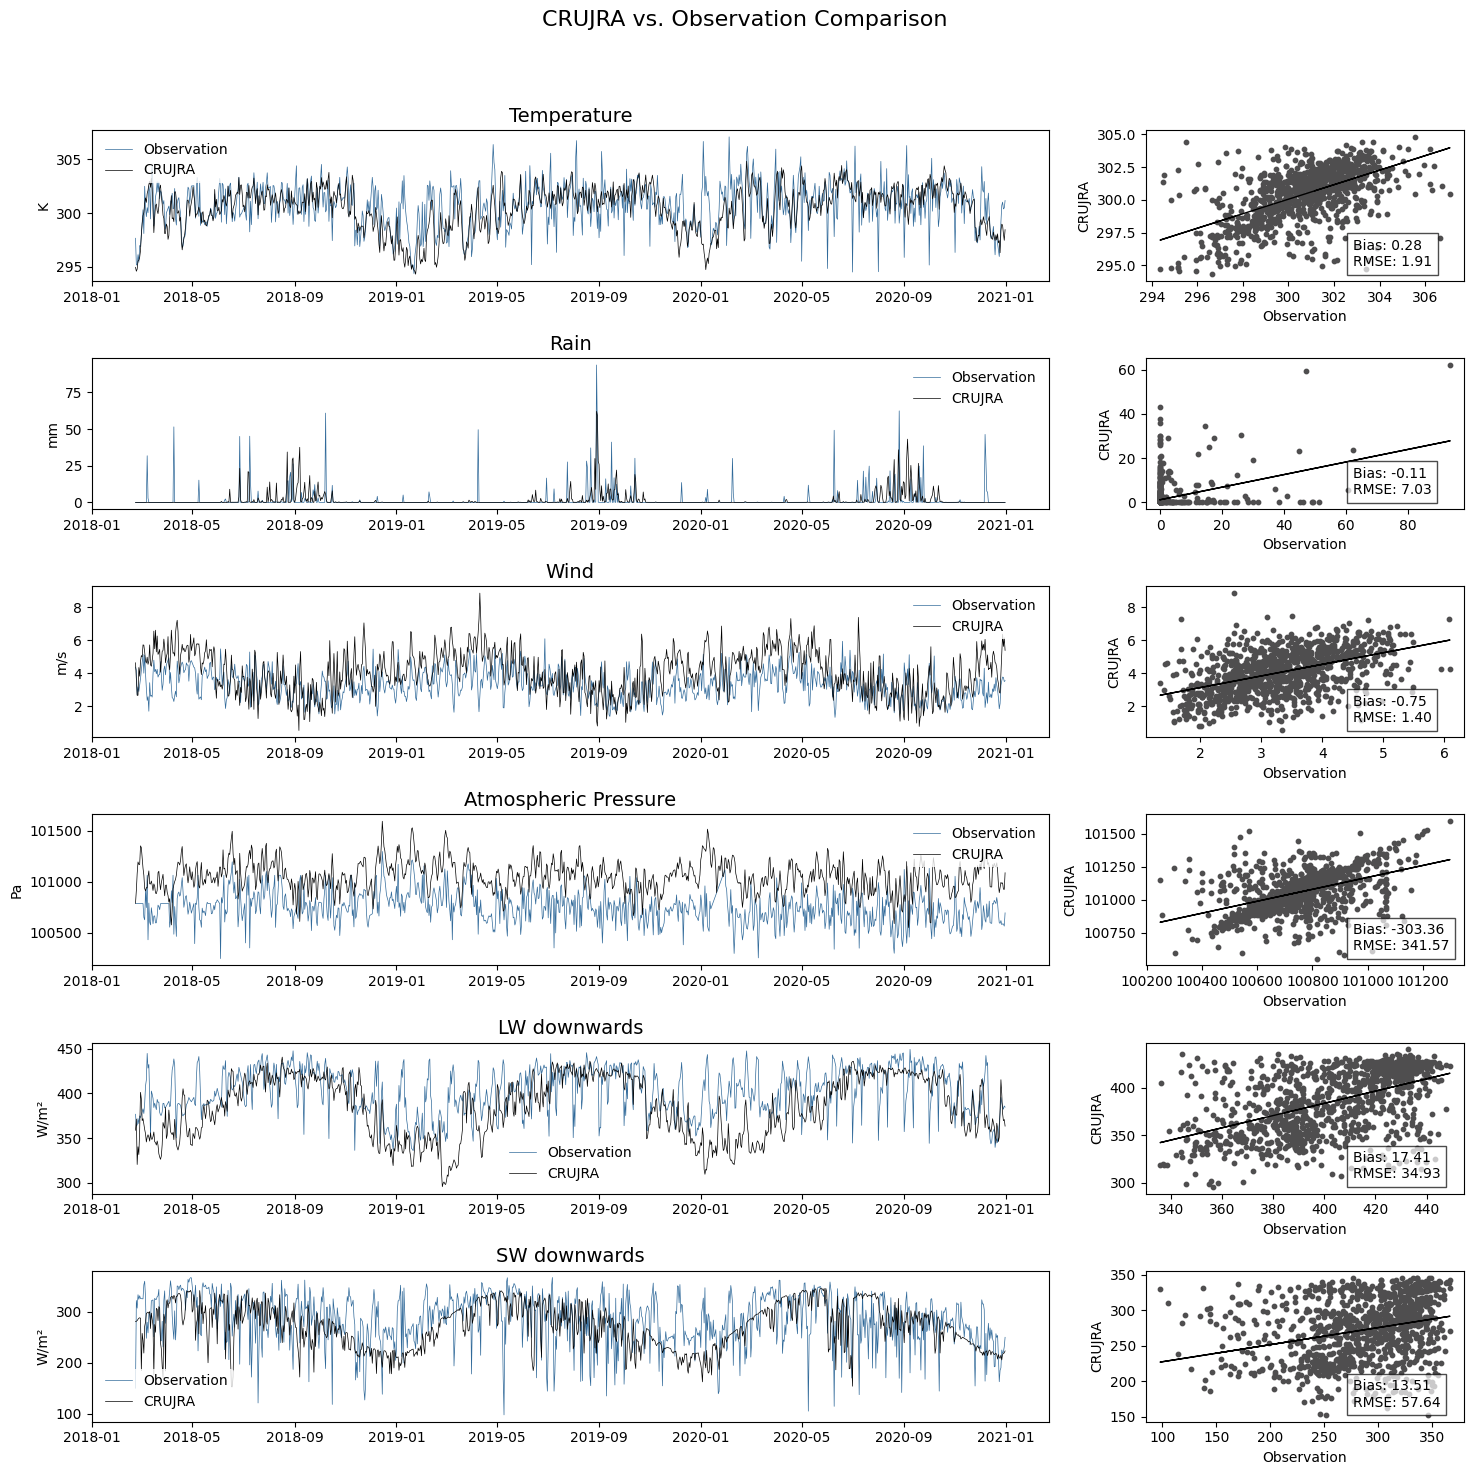

In [237]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Dataframes
model = crujra_df_to_plot
obs = ff_w_obs_to_plot

# Variables and units
variables_to_plot = ["Tair", "Rainf", "Wind_D", "PSurf", "LWdown", "SWdown"]
units = ["K", "mm", "m/s", "Pa", "W/m²", "W/m²"]
names_variables_to_plot = ["Temperature", "Rain", "Wind", "Atmospheric Pressure", "LW downwards", "SW downwards"]
color_code_1 = "black"
color_code_2 = "#316a9a"

# Fill missing values by interpolating
for variable in variables_to_plot:
    model[variable] = model[variable].interpolate()
    obs[variable] = obs[variable].interpolate()

# Create subplots for each variable
fig, axes = plt.subplots(len(variables_to_plot), 2, figsize=(15, 15), gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle("CRUJRA vs. Observation Comparison", fontsize=16)

for i, variable in enumerate(variables_to_plot):
    ax1 = axes[i, 0]  # Left axis for line plot
    ax2 = axes[i, 1]  # Right axis for scatter plot

    # Line plot
    ax1.plot(obs.index, obs[variable], label='Observation', lw=0.5, linestyle='-', color=color_code_2)
    ax1.plot(model.index, model[variable], label='CRUJRA', lw=0.5, color=color_code_1)
    ax1.set_title(names_variables_to_plot[i], fontsize=14)
    ax1.set_xlabel(' ')
    ax1.set_ylabel(f'{units[i]}')
    # ax1.grid(True)

    # Scatter plot with obs on the x-axis and model on the y-axis
    ax2.scatter(obs[variable], model[variable], color="#4f4e4f", s=10)
    ax2.set_xlabel(f'Observation')
    ax2.set_ylabel(f'CRUJRA')

    # Calculate linear regression parameters
    slope, intercept, r_value, p_value, std_err = linregress(obs[variable], model[variable])

    # Plot regression line
    ax2.plot(obs[variable], slope * obs[variable] + intercept, color=color_code_1, linewidth=1)

    # Calculate bias (mean error)
    bias = np.mean(obs[variable] - model[variable])

    # Calculate RMSE
    rmse = np.sqrt(np.mean((obs[variable] - model[variable]) ** 2))

    # Remove the frame around the legend for both subplots
    legend1 = ax1.legend()
    legend1.get_frame().set_linewidth(0)

    # Annotate the plot with bias and RMSE
    ax2.annotate(f'Bias: {bias:.2f}\nRMSE: {rmse:.2f}', xy=(0.65, 0.1), xycoords='axes fraction', fontsize=10, color=color_code_1, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


In [240]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_bias_rmse_correction(model_data, obs_data):
    """
    Calculate the bias, RMSE, and correction factor for each variable.

    Args:
    - model_data (pd.DataFrame): DataFrame containing model values for each variable.
    - obs_data (pd.DataFrame): DataFrame containing observation values for each variable.

    Returns:
    - results (pd.DataFrame): DataFrame with bias, RMSE, and correction factor for each variable.
    """
    results = pd.DataFrame(index=model_data.columns)
    # Fill missing values by interpolating
    for variable in variables_to_plot:
        model[variable] = model[variable].interpolate()
        obs[variable] = obs[variable].interpolate()

    for variable in model_data.columns:
        model_values = model_data[variable]
        obs_values = obs_data[variable]

        # Calculate bias
        bias = model_values - obs_values

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(obs_values, model_values))

        # Calculate correction factor
        correction_factor = obs_values.mean() / model_values.mean()

        results.loc[variable, 'Bias'] = round(bias.mean(), 2)
        results.loc[variable, 'RMSE'] = round(rmse, 2)
        results.loc[variable, 'Correction Factor'] = round(correction_factor, 2)

    return results

results = calculate_bias_rmse_correction(model, obs)
results


,Bias,RMSE,Correction Factor
LWdown,-17.41,34.93,1.05
PSurf,303.36,341.57,1.00
Rainf,0.11,7.03,0.93
SWdown,-13.51,57.64,1.05
Tair,-0.28,1.91,1.00
Wind_D,0.75,1.40,0.82
